In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
iris = load_iris()

In [6]:
df = pd.DataFrame(iris.data)

In [7]:
df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
df.tail()

,0,1,2,3
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [11]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [12]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [9]:
df = pd.DataFrame(data=iris.data,columns=iris.feature_names)

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
df['species'] = iris.target

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
df['species'] = df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})

In [17]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
print(df.shape)

(150, 5)


In [19]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


In [22]:
print(df.describe)

<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1

In [23]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [24]:
print(df.duplicated().sum())

1


In [25]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
142,5.8,2.7,5.1,1.9,virginica


In [26]:
df[df.duplicated(keep=False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [27]:
df = df.drop_duplicates()

In [28]:
print(df.duplicated().sum())

0


In [29]:
print(df.shape)

(149, 5)


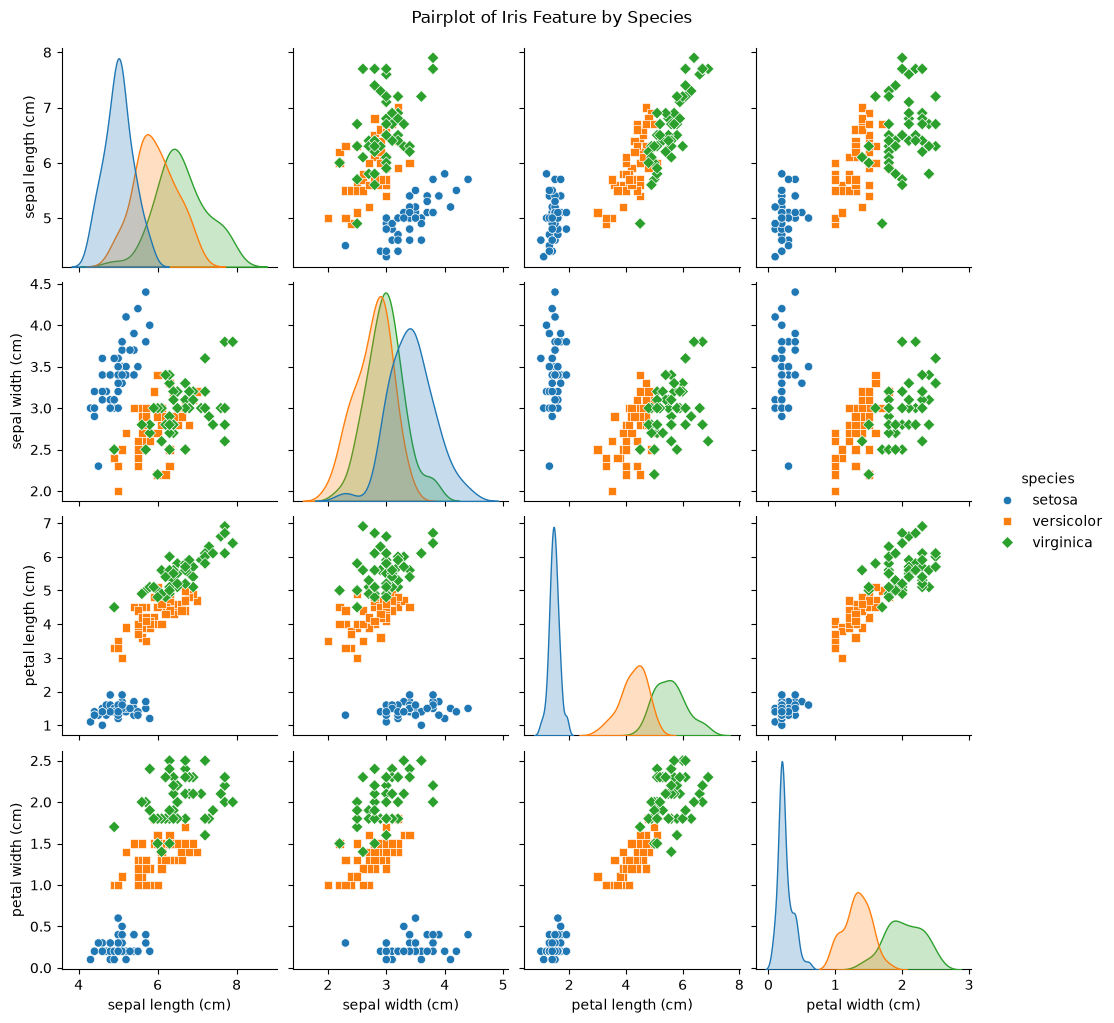

In [33]:
# 1. Pairplot to see feature distributions by species

sns.pairplot(df,hue="species",markers=["o","s","D"])
plt.suptitle("Pairplot of Iris Feature by Species",y=1.02)
plt.show()

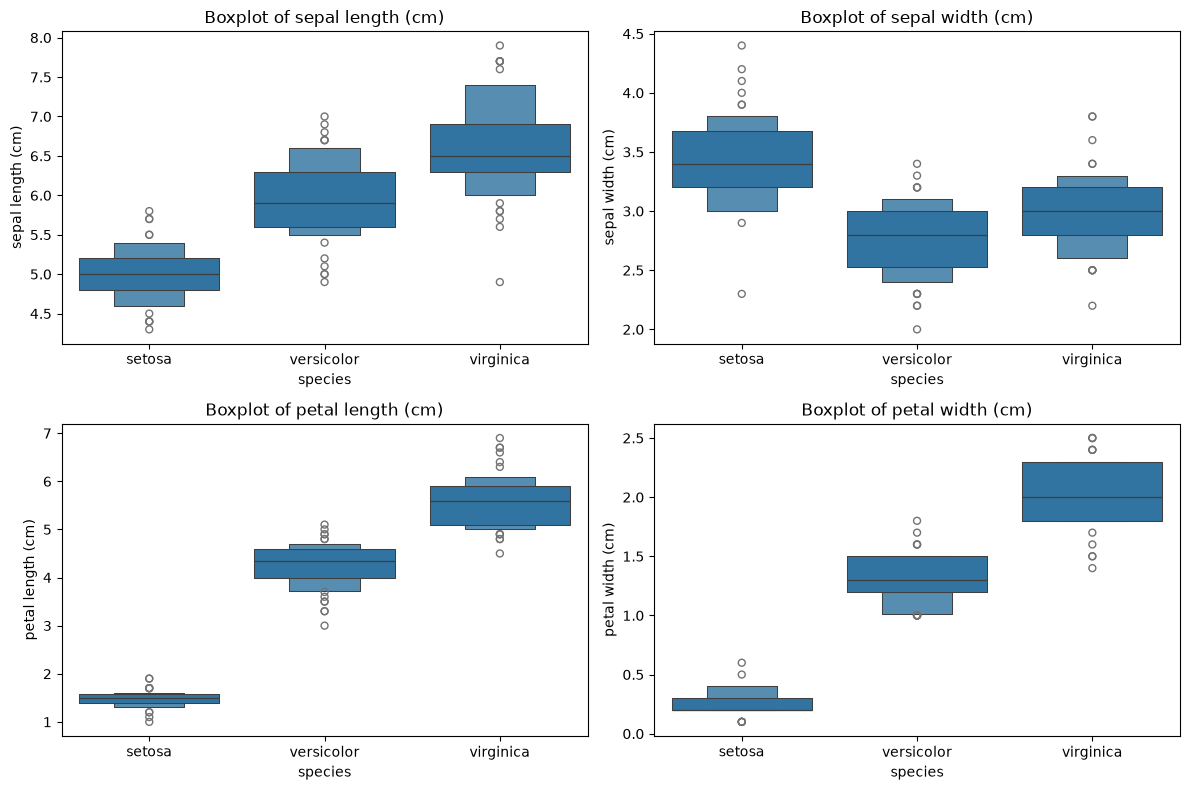

In [39]:
plt.figure(figsize=(12,8))

for i , feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxenplot(x='species',y=feature,data=df)
    plt.title(f"Boxplot of {feature}")
plt.tight_layout()
plt.show()

Feature Selection Observation:
Looking at the pairplot and boxplots, 'petal length (cm)' and 'petal width (cm)' 
are the most discriminative features. They show clear separation between the three 
species, whereas 'sepal length' and 'sepal width' have a lot of overlapping data 
points, especially between Versicolor and Virginica.

In [40]:
# Separate features (X) and target (y)

X = df.drop('species',axis=1)
y = df['species']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (119, 4)
Testing data shape: (30, 4)


In [43]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train,y_train)
print("models trained successfully!")

models trained successfully!


In [44]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
print("models trained successfully!")

models trained successfully!


In [45]:
lr_prediction = lr_model.predict(X_test)

In [46]:
dt_prediction = dt_model.predict(X_test)

In [47]:
print("=== Logistic Regression Evaluation ===")
print("Accuracy Score:", accuracy_score(y_test, lr_prediction))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_prediction))
print("\nClassification Report:\n", classification_report(y_test, lr_prediction))

=== Logistic Regression Evaluation ===
Accuracy Score: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [48]:
# Evaluation for Decision Tree
print("\n=== Decision Tree Evaluation ===")
print("Accuracy Score:", accuracy_score(y_test, dt_prediction))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_prediction))
print("\nClassification Report:\n", classification_report(y_test, dt_prediction))


=== Decision Tree Evaluation ===
Accuracy Score: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



"""
Conclusion & Best-Performing Model:
Both the Logistic Regression and Decision Tree models performed exceptionally well on 
this dataset, often achieving 100% accuracy on the test set. 

However, Logistic Regression is declared the best-performing model here. For small, linearly 
separable datasets (like Iris, especially driven by petal length/width), Logistic Regression 
is less prone to overfitting compared to Decision Trees and provides a robust probabilistic 
understanding of the classification.
"""